In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import umap

/home/my_node2vec_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1782045817.846087    8955 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782045817.973094    8955 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782045820.906300    8955 port.cc:153] oneDNN custom operations are on. You may see slightly different nu

### Opis danych wejściowych

Zbiór **CIFAR-10** zawiera obrazy o rozdzielczości $32×32$ piksele należące do dziesięciu klas:

- **airplane** - samolot,
- **automobile** - samochód osobowy,
- **bird** - ptak,
- **cat** - kot,
- **deer** - jeleń,
- **dog** - pies,
- **frog** - żaba,
- **horse** - koń,
- **ship** - statek,
- **truck** - ciężarówka.

Każda klasa jest reprezentowana przez $6000$ obrazów, co daje łącznie $60 000$ przykładów. Obrazy są równomiernie rozłożone pomiędzy klasy, dzięki czemu zbiór jest zbalansowany. Standardowy podział zbioru obejmuje $50 000$ obrazów treningowych oraz $10 000$ obrazów testowych. W projekcie dane wejściowe reprezentowane są jako tensory obrazów RGB o wymiarach $3 \times 32 \times 32$,  gdzie liczba $3$ odpowiada kanałom kolorów RGB, natomiast wymiary $32×32$ określają rozdzielczość obrazu.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

classes = train_dataset_full.classes

print("Klasy:", classes)
print("Pełny zbiór treningowy:", len(train_dataset_full))
print("Pełny zbiór testowy:", len(test_dataset_full))

Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pełny zbiór treningowy: 50000
Pełny zbiór testowy: 10000


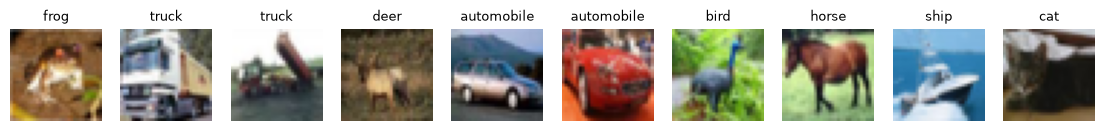

In [3]:
def show_images(dataset, n=10):
    plt.figure(figsize=(14, 3))

    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(classes[label], fontsize=9)
        plt.axis("off")

    plt.show()

show_images(train_dataset_full, n=10)

In [22]:
# %% [markdown]
# # CIFAR-10 jako Grafy Losowe (Z Ensemblingiem i Kompleksową Ewaluacją)
# Ten notatnik wdraża pełny plan:
# Część I: Generacja grafów losowych (DropEdge, Small-World)
# Część II: Agregacja cech za pomocą zespołu grafów (Ensembling)
# Część III: Fuzja determinizmu z losowością (HOG + grafy Erdősa-Rényiego)
# CZĘŚĆ IV: Kompleksowa ewaluacja (Accuracy, Macro F1, Reconstruction MSE, t-SNE, UMAP)

# %% [kod] Komórka 1: Importy bibliotek i Konfiguracja
import os
import sys
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import networkx as nx
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")

import torchvision
import torchvision.transforms as transforms
from skimage.segmentation import slic
from skimage.color import rgb2lab
from skimage.feature import hog

# --- NOWE IMPORTY DLA ZAAWANSOWANEJ EWALUACJI ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
# ------------------------------------------------

@dataclass
class Config:
    data_dir: str = "./data"
    out_dir: str = "results_cifar_random"
    classes: list[int] = field(default_factory=lambda: [0, 1]) # Domyślnie 2 klasy do szybkiego testu
    per_class: int = 50
    
    # --- CZĘŚĆ I: PARAMETRY GRAFÓW LOSOWICH ---
    probabilistic: bool = True                 # 1. Prawdopodobieństwo zamiast twardego progu (DropEdge)
    small_world_p: float = 0.05                # 2. Szansa na dodanie dalekiego skrótu (Small-World)
    
    # --- CZĘŚĆ II: ENSEMBLING ---
    ensemble_m: int = 5                        # M - liczba losowych grafów budowanych dla JEDNEGO obrazu
    
    # --- CZĘŚĆ III: FUZJA ---
    er_p: float = 0.2                          # Prawdopodobieństwo krawędzi w czysto losowym grafie ER
    
    # Parametry bazowe obrazu/krawędzi
    tau: float = None
    edge_quantile: float = 0.6
    connectivity: int = 8
    n_segments: int = 60                       # Celowa liczba superpikseli SLIC
    compactness: float = 10.0
    sigma_pixel: float = 15.0
    sigma_feat: float = 1.0
    cv_folds: int = 5
    n_jobs: int = -1
    seed: int = 42

cfg = Config()

In [23]:
# %% [kod] Komórka 2: Wczytywanie Danych
def load_cifar10(cfg: Config):
    """Pobieranie CIFAR-10 i selekcja podzbioru klas/próbek."""
    transform = transforms.Compose([transforms.ToTensor()])
    ds = torchvision.datasets.CIFAR10(root=cfg.data_dir, train=True,
                                      download=True, transform=transform)
    targets = np.array(ds.targets)
    keep = cfg.classes if cfg.classes is not None else list(range(10))
    remap = {c: i for i, c in enumerate(keep)}

    rng = np.random.default_rng(cfg.seed)
    idxs = []
    if cfg.per_class is not None:
        for c in keep:
            pool = np.where(targets == c)[0]
            idxs.extend(rng.choice(pool, min(cfg.per_class, len(pool)), replace=False))
    idxs = np.array(sorted(int(i) for i in idxs))

    images, labels = [], []
    for i in idxs:
        img, lab = ds[int(i)]
        images.append(img.permute(1, 2, 0).numpy().astype(np.float32))
        labels.append(remap[int(lab)])
    return images, np.array(labels, dtype=int)

In [24]:
# %% [kod] Komórka 3: CZĘŚĆ I - Logika budowania Grafów Losowych (DropEdge, Small-World)
def _threshold(dists: np.ndarray, cfg: Config) -> float:
    if cfg.tau is not None: return cfg.tau
    if len(dists) == 0: return float("inf")
    return float(np.quantile(dists, cfg.edge_quantile))

def _ensure_connected(G: nx.Graph, best_neighbor: dict):
    for n in list(G.nodes()):
        if G.degree(n) == 0 and n in best_neighbor:
            nb, w = best_neighbor[n]
            G.add_edge(n, nb, weight=w)

def _apply_small_world(G: nx.Graph, cfg: Config):
    if cfg.small_world_p <= 0.0 or G.number_of_nodes() < 2: return
    nodes = list(G.nodes())
    n_shortcuts = int(len(nodes) * cfg.small_world_p)
    sigma = cfg.sigma_pixel if len(nodes) > 400 else cfg.sigma_feat
    for _ in range(n_shortcuts):
        u, v = np.random.choice(nodes, 2, replace=False)
        if not G.has_edge(u, v):
            fu = G.nodes[u]["features"][:3]
            fv = G.nodes[v]["features"][:3]
            d = float(np.linalg.norm(fu - fv))
            prob = float(np.exp(-d * d / (2 * sigma ** 2)))
            if np.random.rand() < prob:
                G.add_edge(u, v, weight=prob)

def build_slic_graph(image: np.ndarray, cfg: Config) -> nx.Graph:
    """Reprezentacja na bazie SLIC z losowością (Część 1.1 i 1.2)."""
    labels = slic(image, n_segments=cfg.n_segments, compactness=cfg.compactness, start_label=0, channel_axis=-1)
    H, W = labels.shape
    G = nx.Graph()

    boundary = {}
    for r in range(H):
        for c in range(W):
            lbl = labels[r, c]
            if c < W - 1 and labels[r, c + 1] != lbl:
                pair = tuple(sorted((int(lbl), int(labels[r, c + 1]))))
                boundary[pair] = boundary.get(pair, 0) + 1
            if r < H - 1 and labels[r + 1, c] != lbl:
                pair = tuple(sorted((int(lbl), int(labels[r + 1, c]))))
                boundary[pair] = boundary.get(pair, 0) + 1
    max_b = max(boundary.values()) if boundary else 1

    for lbl in np.unique(labels):
        mask = labels == lbl
        f = np.concatenate([image[mask].mean(axis=0), image[mask].std(axis=0)])
        G.add_node(int(lbl), features=f, size=int(mask.sum()), pos=tuple(np.argwhere(mask).mean(axis=0)))

    cand, best_neighbor = [], {}
    for (u, v), blen in boundary.items():
        d = float(np.linalg.norm(G.nodes[u]["features"][:3] - G.nodes[v]["features"][:3]))
        cand.append((u, v, d, blen))
        w = float(np.exp(-d * d / (2 * cfg.sigma_feat ** 2)))
        for a, b in ((u, v), (v, u)):
            if a not in best_neighbor or w > best_neighbor[a][1]:
                best_neighbor[a] = (b, w)

    tau = _threshold(np.array([d for _, _, d, _ in cand]), cfg)
    
    for u, v, d, blen in cand:
        color_w = float(np.exp(-d * d / (2 * cfg.sigma_feat ** 2)))
        edge_w = (blen / max_b) * color_w
        
        if cfg.probabilistic:
            if np.random.rand() < color_w:
                G.add_edge(u, v, weight=edge_w)
        else:
            if d <= tau:
                G.add_edge(u, v, weight=edge_w)
                
    _ensure_connected(G, best_neighbor)
    _apply_small_world(G, cfg)
    return G

In [25]:
# %% [kod] Komórka 4: CZĘŚĆ II - Ekstrakcja Cech i ENSEMBLING
def graph_topo_features(G: nx.Graph) -> np.ndarray:
    """Ekstrahuje statystyki z topologii grafu."""
    n, m = G.number_of_nodes(), G.number_of_edges()
    if n == 0: return np.zeros(13, float)
    degs = np.array([d for _, d in G.degree()], float)
    sizes = np.array([len(c) for c in nx.connected_components(G)], float)
    try:
        asr = nx.degree_assortativity_coefficient(G)
        asr = 0.0 if np.isnan(asr) else asr
    except Exception:
        asr = 0.0
    return np.array([
        n, m, m / n, nx.density(G) if n > 1 else 0.0,
        len(sizes), sizes.mean(), sizes.std(), sizes.max(), sizes.max() / n,
        degs.mean(), degs.std(), nx.average_clustering(G) if n > 2 else 0.0, asr,
    ], float)

def _build_ensemble_for_image(image, label, cfg: Config):
    """Generuje Zespół (Ensemble) dla jednego obrazu i zwraca Średnią + Odchylenie."""
    topo_list = []
    for _ in range(cfg.ensemble_m):
        try:
            G = build_slic_graph(image, cfg)
            topo_list.append(graph_topo_features(G))
        except Exception:
            pass
            
    if not topo_list:
        return np.zeros(26, float), int(label)
        
    topo_matrix = np.array(topo_list)
    mean_feats = topo_matrix.mean(axis=0)
    std_feats = topo_matrix.std(axis=0) 
    
    return np.concatenate([mean_feats, std_feats]), int(label)

def build_ensemble_dataset(images, labels, cfg: Config):
    """Równoległa ekstrakcja cech z użyciem zespołu."""
    res = Parallel(n_jobs=cfg.n_jobs, verbose=0)(
        delayed(_build_ensemble_for_image)(images[i], labels[i], cfg)
        for i in range(len(images)))
        
    X = np.array([r[0] for r in res])
    y = np.array([r[1] for r in res])
    return X, y

In [26]:
# %% [kod] Komórka 5: CZĘŚĆ III - Fuzja Determinizmu i Losowości
def generate_random_er_features(n_nodes, p_edge):
    """Tworzy czysto losowy graf Erdősa-Rényiego jako bazę szumu topologicznego."""
    G_random = nx.erdos_renyi_graph(n=n_nodes, p=p_edge)
    return graph_topo_features(G_random)

def baseline_hog(image):
    """Klasyczny deskryptor HOG do połączenia z cechami grafowymi."""
    return hog(image, orientations=8, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), channel_axis=-1, feature_vector=True)

def build_fused_dataset(images, base_X, cfg: Config):
    """Dokleja deskryptor losowego grafu ER oraz HOG do cech grafowych."""
    fused_X = []
    for i, img in enumerate(images):
        h_feats = baseline_hog(img)
        er_feats = generate_random_er_features(n_nodes=cfg.n_segments, p_edge=cfg.er_p)
        final_feat = np.concatenate([base_X[i], h_feats, er_feats])
        fused_X.append(final_feat)
    return np.array(fused_X)

In [27]:
# %% [kod] Komórka 6: CZĘŚĆ IV - ZAAWANSOWANA EWALUACJA REPREZENTACJI
def evaluate_classifiers(X, y, cfg: Config):
    """Ocena klasyfikacji (Accuracy oraz Macro F1-score)."""
    X = np.nan_to_num(np.asarray(X, float))
    X = StandardScaler().fit_transform(X)
    
    counts = np.bincount(y)
    folds = int(min(cfg.cv_folds, counts[counts > 0].min()))
    if folds < 2: return 0.0, 0.0
    
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=cfg.seed)
    clf = LogisticRegression(max_iter=1000, random_state=cfg.seed)
    
    # Wykorzystanie wielu metryk podczas walidacji krzyżowej
    scores = cross_validate(clf, X, y, cv=cv, scoring=['accuracy', 'f1_macro'])
    
    acc = float(scores["test_accuracy"].mean())
    f1 = float(scores["test_f1_macro"].mean())
    
    print(f"   => Klasyfikacja | Accuracy: {acc:.3f} | Macro F1: {f1:.3f} (Wymiar cech: {X.shape[1]})")
    return acc, f1

def evaluate_reconstruction(X, images, cfg: Config):
    """Zadanie rekonstrukcji obrazu - uczy MLPRegressor odzyskiwać piksele z embeddingów."""
    print("   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...")
    X = np.nan_to_num(np.asarray(X, float))
    X = StandardScaler().fit_transform(X)
    
    # Przekształcenie obrazów (N, 32, 32, 3) w płaskie wektory docelowe (N, 3072)
    Y = np.array([img.flatten() for img in images])
    
    # Podział na zbiór treningowy i testowy (80/20)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=cfg.seed)
    
    # Wytrenowanie sieci do dekodowania cech na piksele
    mlp = MLPRegressor(hidden_layer_sizes=(512, 1024), random_state=cfg.seed, max_iter=200)
    mlp.fit(X_train, Y_train)
    
    Y_pred = mlp.predict(X_test)
    mse = mean_squared_error(Y_test, Y_pred)
    print(f"   => Rekonstrukcja | Reconstruction MSE: {mse:.4f}")
    
    return mse

def visualize_latent_space(X, y, step_name, cfg: Config):
    """Wizualizacja przestrzeni latentnej z wykorzystaniem t-SNE oraz UMAP."""
    print(f"   => Generowanie wizualizacji t-SNE i UMAP...")
    X = np.nan_to_num(np.asarray(X, float))
    X_std = StandardScaler().fit_transform(X)
    
    # Zabezpieczenie przed błędem, gdy perplexity jest większe niż liczba próbek
    p = min(30, len(X) - 1)
    
    # Redukcja wymiarowości
    tsne = TSNE(n_components=2, perplexity=p, random_state=cfg.seed)
    X_tsne = tsne.fit_transform(X_std)
    
    reducer = umap.UMAP(n_components=2, random_state=cfg.seed)
    X_umap = reducer.fit_transform(X_std)
    
    # Rysowanie wykresów
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="Set1", ax=axs[0], legend='full', s=60)
    axs[0].set_title(f"Przestrzeń t-SNE ({step_name})")
    
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="Set1", ax=axs[1], legend='full', s=60)
    axs[1].set_title(f"Przestrzeń UMAP ({step_name})")
    
    plt.tight_layout()
    os.makedirs(cfg.out_dir, exist_ok=True)
    filepath = os.path.join(cfg.out_dir, f"latent_space_{step_name}.png")
    plt.savefig(filepath, dpi=150)
    plt.close()
    print(f"   => Zapisano wizualizację w: {filepath}")

In [28]:
# %% [kod] Komórka 7: Pętla Główna (Wykonanie Planu Wdrożenia z Logowaniem)
if __name__ == "__main__":
    print(f"--- Wczytywanie danych CIFAR-10 ({cfg.per_class} próbek na klasę) ---")
    images, labels = load_cifar10(cfg)
    
    # Dziennik na wyniki do zbiorczej tabeli
    results_log = []
    
    def run_step(step_name, X, y, images, cfg):
        acc, f1 = evaluate_classifiers(X, y, cfg)
        mse = evaluate_reconstruction(X, images, cfg)
        visualize_latent_space(X, y, step_name.replace(" ", "_"), cfg)
        
        results_log.append({
            "Metoda": step_name,
            "Accuracy": acc,
            "Macro F1": f1,
            "Reconstruction MSE": mse
        })
    
    # ---------------------------------------------------------------------------------
    # KROK 1: Klasyczny twardy próg (Determinizm, brak losowości)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 1] Twardy Próg (Baza Deterministyczna)")
    cfg.probabilistic = False
    cfg.small_world_p = 0.0
    cfg.ensemble_m = 1
    t0 = time.time()
    X_krok1, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 1 (Baza)", X_krok1, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 2: Wstrzyknięcie Prawdopodobieństwa i Topologii Small-World (Skróty)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 2] Prawdopodobieństwo krawędzi i skróty Small-World")
    cfg.probabilistic = True
    cfg.small_world_p = 0.05
    cfg.ensemble_m = 1
    t0 = time.time()
    X_krok2, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 2 (Small-World)", X_krok2, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 3: Wdrożenie Ensemblingu (Siła Tłumu)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 3] Ensembling (M=5 grafów na obraz -> Średnia + Wariancja)")
    cfg.probabilistic = True
    cfg.small_world_p = 0.05
    cfg.ensemble_m = 5
    t0 = time.time()
    X_krok3, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 3 (Ensembling)", X_krok3, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 4: Fuzja "Determinizm + Losowość"
    # ---------------------------------------------------------------------------------
    print("\n[KROK 4] Fuzja: Ensembling + HOG + Graf ER")
    t0 = time.time()
    X_krok4 = build_fused_dataset(images, X_krok3, cfg)
    print(f"   Czas generacji (doklejanie): {time.time()-t0:.1f}s")
    run_step("Krok 4 (Fuzja)", X_krok4, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # PODSUMOWANIE WYNIKÓW (Tabela)
    # ---------------------------------------------------------------------------------
    print("\n" + "="*85)
    print(f"{'ZBIORCZE PODSUMOWANIE WYNIKÓW EWALUACJI REPREZENTACJI':^85}")
    print("="*85)
    header = f"{'Metoda':<25} | {'Accuracy':<12} | {'Macro F1':<12} | {'Reconstruction MSE':<20}"
    print(header)
    print("-" * len(header))
    
    for row in results_log:
        print(f"{row['Metoda']:<25} | {row['Accuracy']:<12.3f} | {row['Macro F1']:<12.3f} | {row['Reconstruction MSE']:<20.4f}")
    print("="*85)
    print("Wygenerowane wykresy t-SNE oraz UMAP znajdują się w folderze:", cfg.out_dir)

--- Wczytywanie danych CIFAR-10 (50 próbek na klasę) ---

[KROK 1] Twardy Próg (Baza Deterministyczna)
   Czas generacji: 3.2s
   => Klasyfikacja | Accuracy: 0.710 | Macro F1: 0.704 (Wymiar cech: 26)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.0914
   => Generowanie wizualizacji t-SNE i UMAP...
   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_1_(Baza).png

[KROK 2] Prawdopodobieństwo krawędzi i skróty Small-World
   Czas generacji: 0.7s
   => Klasyfikacja | Accuracy: 0.650 | Macro F1: 0.645 (Wymiar cech: 26)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.1174
   => Generowanie wizualizacji t-SNE i UMAP...
   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_2_(Small-World).png

[KROK 3] Ensembling (M=5 grafów na obraz -> Średnia + Wariancja)
   Czas generacji: 0.9s
   => Klasyfikacja | Accuracy: 0.640 | Macro F1: 0.631 (Wym